# IHS - Climate Concern and Personal Responsibility in Austria - Project

My (mini-)project will be about the following question:

### Climate Concern and Personal Responsibility in Austria

**Is greater concern about climate change associated with a stronger sense of personal responsibility to reduce it?**

I chose this question because it fits quite well with the topics of the IHS - Social Sustainable Transformation group, especially its work on climate change from a social science and behavioral economics perspective, as well as working with survey data.

Now, the idea is very simple, I am basically going to look at whether respondents who report being more worried about climate change also feel a stronger personal responsibility to contribute to reducing it.

For that I will be using ESS Round 11 data as well as the corresponding codebook.

## 1. First steps - Loading Packages and Data

In [1]:
###### Packages #####

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf

Now off to loading the dataset:

I am using the [ESS Round 11 Integrated File, Edition 4.2](https://ess.sikt.no/en/datafile/242aaa39-3bbb-40f5-98bf-bfb1ce53d8ef) from the ESS, which I downloaded as a csv. One can easily load the data by using pandas and the ``.read_csv()`` - method.

In [2]:
# Loading the raw data
raw_data = pd.read_csv("../Data/ESS11e04_2.csv", low_memory=False)

# Getting a quick overview of the data. 
# low_memory=False read the full CSV at once to avoid mixed-type warnings.
# Just typing the name of the dataframe will give us a quick overview of the data, 
# including the number of rows and columns, as well as the first and last five rows of the data. 

raw_data

,name,essround,edition,proddate,idno,cntry,dweight,pspwght,pweight,anweight,...,rinwe,inwde,jinws,jinwe,inwtm,mode,domain,prob,stratum,psu
0,ESS11e04_2,11,4.2,02.07.2026,50014,AT,1.185115,0.392891,0.330915,0.130013,...,NaN,2023-11-12 15:26:55,2023-11-12 15:21:28,2023-11-12 15:26:55,30.0,1,2.0,0.000579,107,317
1,ESS11e04_2,11,4.2,02.07.2026,50030,AT,0.609898,0.325153,0.330915,0.107598,...,NaN,2023-10-18 10:44:18,2023-10-18 10:42:22,2023-10-18 10:44:18,40.0,1,1.0,0.001124,69,128
2,ESS11e04_2,11,4.2,02.07.2026,50057,AT,1.392330,4.000023,0.330915,1.323666,...,NaN,2023-09-30 14:13:33,2023-09-30 14:08:31,2023-09-30 14:13:33,42.0,1,2.0,0.000493,18,418
3,ESS11e04_2,11,4.2,02.07.2026,50106,AT,0.556062,0.176228,0.330915,0.058316,...,NaN,2023-06-30 15:11:21,2023-06-30 15:08:05,2023-06-30 15:11:21,34.0,1,1.0,0.001233,101,295
4,ESS11e04_2,11,4.2,02.07.2026,50145,AT,0.722795,1.060940,0.330915,0.351080,...,NaN,2023-07-11 11:14:03,2023-07-11 11:10:02,2023-07-11 11:14:03,57.0,1,2.0,0.000949,115,344
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
50111,ESS11e04_2,11,4.2,02.07.2026,273742,UA,1.194824,1.194824,1.310703,1.566060,...,NaN,2024-05-20 21:19:06,2024-05-20 21:19:15,2024-05-20 21:22:56,37.0,1,1.0,0.000184,1492,25303
50112,ESS11e04_2,11,4.2,02.07.2026,273743,UA,0.436757,0.436757,1.310703,0.572459,...,NaN,2024-05-11 12:09:29,2024-05-11 12:09:36,2024-05-11 12:21:45,33.0,1,2.0,0.000505,1516,25311
50113,ESS11e04_2,11,4.2,02.07.2026,273747,UA,1.067750,1.067750,1.310703,1.399503,...,NaN,2024-05-23 15:50:19,2024-05-23 15:50:27,2024-05-23 15:54:37,29.0,1,1.0,0.000206,1495,25334
50114,ESS11e04_2,11,4.2,02.07.2026,273838,UA,0.597412,0.597412,1.310703,0.783030,...,NaN,2024-05-08 13:32:18,2024-05-08 13:32:23,2024-05-08 13:39:30,53.0,1,1.0,0.000369,1492,25303


Okay, so we can see that this is a pretty large dataset: 50,116 rows and 691 columns.

The data itself looks pretty good, and is already pretty much fit for work - the ESS data is cross-sectional and already arranged with one respondent per row and the variables in separate columns. So no need for reshaping or transform the data first, we can move directly to identifying observations and variables that are relevant.

The 50,116 rows are not Austrian respondents only, but respondents from all countries included in ESS Round 11. According to the Austrian ESS report, the Austrian sample itself contains 2,354 respondents, meaning we will have to kick most of the rows (Countries other than Austria) and keep Austria only.

The 691 columns represent all the different variables included in the dataset, far more than we need for this project.

Which is also our next step, figuring out and motivating which variables will be helpful for our project. For this the codebook will be very helpful, and serve as a source for which variables to use.  

## 2. Choosing the relevant variables for Austria

Now to build a dataset with only relevant data, we have to see which variables are useful for our purpose and choose them as a new dataset.

Looking through the codebook, the following variables seem helpful:

Outcome-Variable:
- `ccrdprs`: To what extent respondents feel a personal responsibility to reduce climate change.

Main Input-Variable:
- `wrclmch`: How worried respondents are about climate change.

Additional Variables:
- `ccnthum`: Whether respondents think climate change is caused by natural processes, human activity or both.
- `agea`: Age.
- `gndr`: Gender.
- `eduyrs`: Years of education.
- `anweight`: The ESS analysis weight.
- `idno`: Respondent ID.
- `cntry`: Country - we want Austria only.

Next step is to create a dataset with exactly these columns, effectively reducing the data to work with:

In [3]:
variables = ["idno", "cntry", "ccrdprs", "wrclmch", "ccnthum", "agea", "gndr", "eduyrs", "anweight"]
variables

['idno',
 'cntry',
 'ccrdprs',
 'wrclmch',
 'ccnthum',
 'agea',
 'gndr',
 'eduyrs',
 'anweight']

Next is to filter for the selected data. Using the .loc method is the cleanest version here, since one pretty much filters like [row-argument, column-argument]:

In [4]:
df =  raw_data.loc[raw_data["cntry"] == "AT", variables].copy()
df

,idno,cntry,ccrdprs,wrclmch,ccnthum,agea,gndr,eduyrs,anweight
0,50014,AT,4,4,4,65,1,12,0.130013
1,50030,AT,10,5,3,21,2,14,0.107598
2,50057,AT,8,5,4,53,2,16,1.323666
3,50106,AT,6,4,4,78,2,14,0.058316
4,50145,AT,10,4,5,64,1,12,0.351080
...,...,...,...,...,...,...,...,...,...
2349,86428,AT,9,4,3,88,2,12,0.260184
2350,86437,AT,6,3,4,67,1,12,0.053822
2351,86454,AT,6,3,4,33,2,9,0.337693
2352,86475,AT,5,3,3,50,1,12,0.162121


## 3. Checking and preparing the data

With our dataset at hand, we should briefly check the data before starting the analysis.

The main things to check are:

- datatypes
- missing values
- whether the observed values correspond to the ranges and special missing-value codes given in the ESS codebook

In [5]:
df.dtypes

idno          int64
cntry        object
ccrdprs       int64
wrclmch       int64
ccnthum       int64
agea          int64
gndr          int64
eduyrs        int64
anweight    float64
dtype: object

Good, the datatypes look fine for our purposes.

Next, we can check whether pandas already recognizes any missing values:

In [6]:
df.isna().sum()

idno        0
cntry       0
ccrdprs     0
wrclmch     0
ccnthum     0
agea        0
gndr        0
eduyrs      0
anweight    0
dtype: int64

So at first glance this looks great, no missing values, but through my work at another project with ESS data, I already know, that this is not the case:

As in many survey datasets, the ESS does not store responses such as `Refusal`, `Don't know` or `No answer` as NaN values, these responses are instead represented by specific numerical codes.

So before we can properly assess any missingness, we first have to check the value ranges given in the codebook and recode these special values as NaN.


Now, according to the ESS codebook, the relevant variables use the following values:

| Variable | Valid values | Missing values |
|---|---|---|
| `ccrdprs` | 0–10 | 66 = Not applicable, 77 = Refusal, 88 = Don't know, 99 = No answer |
| `wrclmch` | 1–5 | 6 = Not applicable, 7 = Refusal, 8 = Don't know, 9 = No answer |
| `ccnthum` | 1–5 and 55 = climate change is not happening | 77 = Refusal, 88 = Don't know, 99 = No answer |
| `agea` | reported age | 999 = Not available |
| `gndr` | 1 = Male, 2 = Female | 9 = No answer |
| `eduyrs` | reported years of education | 77 = Refusal, 88 = Don't know, 99 = No answer |

`idno`, `cntry` and `anweight` do not require the same recoding step.


We should check the three main variables: `ccrdprs`, `wrclmch` & `ccnthum` individually; starting with `ccrdprs`:

In [7]:
df["ccrdprs"].value_counts().sort_index()

ccrdprs
0      83
1      48
2      91
3     148
4     141
5     370
6     242
7     373
8     412
9     210
10    200
66      6
77      5
88     25
Name: count, dtype: int64

Okay, so these values look plausible and correspond to the ESS codebook, with most respondents using the regular 0–10 response scale.

We can also see the special missing-value codes: 6 observations are coded as `Not applicable` (66), 5 as `Refusal` (77) and 25 as `Don't know` (88). This gives us 36 observations that should become NaN after recoding.

In [8]:
display(df["wrclmch"].value_counts().sort_index()) 
display(df["ccnthum"].value_counts().sort_index())

wrclmch
1     65
2    291
3    992
4    781
5    215
6      6
7      2
8      2
Name: count, dtype: int64

ccnthum
1       33
2      166
3      929
4     1028
5      154
55       6
77       1
88      37
Name: count, dtype: int64

The values for both variables also correspond to the ESS codebook:

For `wrclmch`, the special missing-value codes occur 10 times in total: 6 observations are coded as `Not applicable` (6), 2 as `Refusal` (7) and 2 as `Don't know` (8).

For `ccnthum`, 1 observation is coded as `Refusal` (77) and 37 as `Don't know` (88), giving us 38 missing observations in total. The value `55` is a valid response indicating that the respondent does not think climate change is happening and should therefore not be treated as missing.

We can now recode the special missing-value categories as NaN.

In [9]:
missing_codes = {
    "ccrdprs": [66, 77, 88, 99],
    "wrclmch": [6, 7, 8, 9],
    "ccnthum": [77, 88, 99],
    "agea": [999],
    "gndr": [9],
    "eduyrs": [77, 88, 99]
}

for vars, codes in missing_codes.items():
    df[vars] = df[vars].replace(codes, np.nan)

Okay, this should do the trick, we should check:

In [10]:
df.isna().sum()

idno         0
cntry        0
ccrdprs     36
wrclmch     10
ccnthum     38
agea         0
gndr         0
eduyrs      46
anweight     0
dtype: int64

Good, the recoding worked as intended. The number of NaN values now matches the special missing-value codes observed before: 36 for `ccrdprs`, 10 for `wrclmch` and 38 for `ccnthum`.

The value `55` in `ccnthum` remains in the data, since it is a valid response rather than a missing value.

With the missing values now properly coded, the data is ready for the descriptive analysis.

## 4. Short Descriptive Analysis

With the data cleaned, we can now take a short look at the main variables before examining the relationship between climate concern and personal responsibility.

In [11]:
df[["ccrdprs", "wrclmch","ccnthum", "agea", "gndr", "eduyrs", "anweight"]].describe().round(2)

,ccrdprs,wrclmch,ccnthum,agea,gndr,eduyrs,anweight
count,2318.00,2344.00,2316.00,2354.00,2354.00,2308.00,2354.00
mean,6.19,3.34,3.61,55.64,1.58,12.65,0.33
std,2.54,0.91,2.73,18.32,0.49,3.42,0.32
min,0.00,1.00,1.00,15.00,1.00,0.00,0.03
25%,5.00,3.00,3.00,42.00,1.00,11.00,0.12
50%,7.00,3.00,4.00,57.00,2.00,12.00,0.22
75%,8.00,4.00,4.00,70.00,2.00,14.00,0.40
max,10.00,5.00,55.00,90.00,2.00,47.00,1.32


The descriptive statistics do not show anything particularly unusual, as personal responsibility has a mean of 6.19 on the 0–10 scale, while average climate concern is 3.34 on the 1–5 scale.

The summary for `ccnthum` should be interpreted with caution, because of valid response code `55` (respondents who do not think climate change is happening), which obviously skews the interpretation.

More importantly for our research question, we can look at the average level of personal responsibility for each level of climate concern.

Since the ESS provides an analysis weight, I will use weighted means for this comparison.

In [12]:
# Keep only observations with valid values for climate concern,
# personal responsibility and the ESS analysis weight.
temp = df.dropna(subset=["wrclmch", "ccrdprs", "anweight"]).copy()

# Multiply each personal-responsibility score by its ESS analysis weight.
# This gives each observation its weighted contribution.
temp["weighted_ccrdprs"] = temp["ccrdprs"] * temp["anweight"]

# Group respondents by their level of climate concern (1 to 5).
# Within each group, sum the weighted responsibility scores and the weights.
weighted_means = temp.groupby("wrclmch").agg(
    weighted_sum=("weighted_ccrdprs", "sum"),
    weight_sum=("anweight", "sum")
)

# Calculate the weighted mean personal-responsibility score for each group:
# sum(weight * responsibility) / sum(weight).
weighted_means["weighted_mean_ccrdprs"] = (
    weighted_means["weighted_sum"] / weighted_means["weight_sum"]
)

# Show only the weighted means, rounded to two decimal places.
weighted_means["weighted_mean_ccrdprs"].round(2)

wrclmch
1.0    2.56
2.0    4.16
3.0    5.78
4.0    7.27
5.0    8.71
Name: weighted_mean_ccrdprs, dtype: float64

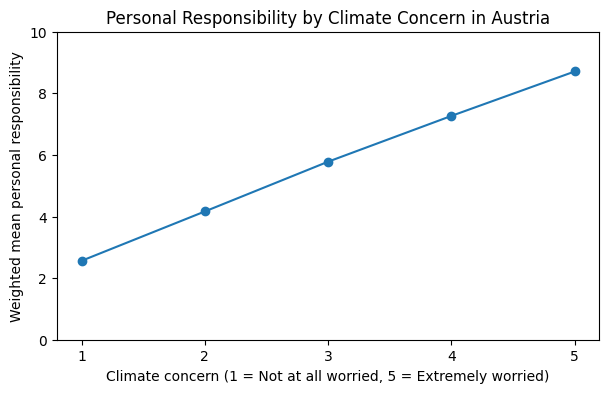

In [13]:
# Create the figure and set its size.
plt.figure(figsize=(7, 4))

# Plot climate concern on the x-axis and the weighted mean
# personal-responsibility score on the y-axis.
plt.plot(
    weighted_means.index,
    weighted_means["weighted_mean_ccrdprs"],
    marker="o"
)

# Add labels describing both axes.
plt.xlabel("Climate concern (1 = Not at all worried, 5 = Extremely worried)")
plt.ylabel("Weighted mean personal responsibility")
plt.title("Personal Responsibility by Climate Concern in Austria")
plt.xticks([1, 2, 3, 4, 5])                                                     # Show all five climate-concern categories on the x-axis.
plt.ylim(0, 10)
plt.show()

The descriptive pattern is very clear: 

Average personal responsibility increases steadily with climate concern. The weighted mean rises from about 2.6 among respondents who are not at all worried about climate change to about 8.7 among those who are extremely worried.

This suggests a fairly strong positive relationship between climate concern and personal responsibility.

 In the next step, I will examine this relationship more formally using a regression.

## 5. Short Regression Analysis

The descriptive results show a clear positive relationship between climate concern and personal responsibility. To examine this relationship more formally, I will estimate a simple weighted regression.

`ccrdprs` is the outcome variable and `wrclmch` is the explanatory variable. The ESS analysis weight is again used to account for differences in the representation of respondents in the sample.

In [14]:
# Estimate a weighted regression of personal responsibility on climate concern.
# The ESS analysis weight determines how strongly each observation contributes
# to the estimation.

model = smf.wls(
    formula="ccrdprs ~ wrclmch",
    data=df,
    weights=df["anweight"]
).fit(cov_type="HC3")   # HC3 provides robust standard errors.

# Show the regression results.
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            WLS Regression Results                            
==============================================================================
Dep. Variable:                ccrdprs   R-squared:                       0.324
Model:                            WLS   Adj. R-squared:                  0.324
Method:                 Least Squares   F-statistic:                     455.8
Date:                Sun, 20 Sep 2026   Prob (F-statistic):           1.87e-92
Time:                        15:49:48   Log-Likelihood:                -5384.4
No. Observations:                2316   AIC:                         1.077e+04
Df Residuals:                    2314   BIC:                         1.078e+04
Df Model:                           1                                         
Covariance Type:                  HC3                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      1.1799      0.252      4.678      0.000       0.686       1.674
wrclmch        1.5201      0.071     21.349      0.000       1.381       1.660
==============================================================================
Omnibus:                      479.800   Durbin-Watson:                   1.916
Prob(Omnibus):                  0.000   Jarque-Bera (JB):             3046.459
Skew:                          -0.822   Prob(JB):                         0.00
Kurtosis:                       8.373   Cond. No.                         14.2
==============================================================================

Notes:
[1] Standard Errors are heteroscedasticity robust (HC3)
"""

The regression confirms the descriptive pattern. A one-category increase in climate concern is associated with an increase of about 1.52 points in personal responsibility on the 0–10 scale.

The relationship is statistically significant (p < 0.001), and the model explains about 32.4% of the variation in personal responsibility. This indicates a substantial positive association between climate concern and perceived personal responsibility.

## 6. Conclusion

The results show a clear positive relationship between climate concern and personal responsibility in Austria, as respondents who are more worried about climate change also tend to report a substantially stronger sense of personal responsibility to help reduce it.

The analysis is based on cross-sectional survey data, so the results should be interpreted as an association rather than a causal effect. It should also be kept in mind that `ccrdprs` measures perceived personal responsibility and not actual climate-related behavior.